예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)
# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 케라스 API로 다시 쓰는 5-3절

> **추가 학습 자료** — 본문 5-3절 「좀 더 복잡한 이미지를 다루는 딥러닝」
> 선수 지식: 5-2절(합성곱 블록), 5-3절(CIFAR-10 분류기, 데이터 증강, 드롭아웃)

이 노트북은 본문 5-3절의 CIFAR-10 분류기를 **케라스 API + 파이토치 백엔드**로 다시 구현한다.
모델의 구조, 하이퍼파라미터, 데이터 준비 과정은 본문과 동일하게 맞추고,
**모델을 정의하고 학습시키는 방식만** 케라스로 바꾼다.

다루는 내용
- 1절 백엔드 지정과 `channels_first` 설정
- 2절 데이터 준비 — 본문 [코드 5-13]을 **그대로** 사용
- 3절 모델 정의 — [코드 5-14]와 대칭
- 4절 `compile()`과 `fit()` — [코드 5-15]의 학습 함수를 대체
- 5절 데이터 증강 — [코드 5-16]~[코드 5-18]과 대칭
- 6절 드롭아웃 — [코드 5-19]와 대칭
- 7절 하드웨어 가속기 — [코드 5-20]~[코드 5-22]와 대칭

## 1. 백엔드 지정

케라스 3은 파이토치, 텐서플로, JAX 중 하나를 골라 그 위에서 동작한다.
어느 것을 쓸지는 **`keras`를 임포트하기 전에** 환경 변수 `KERAS_BACKEND`로 정한다.
임포트한 뒤에 바꾸면 반영되지 않으므로 순서가 중요하다.

여기에 한 가지를 더 맞춰야 한다. 케라스의 기본 이미지 형식은 채널이 마지막에 오는
`(B, H, W, C)`이지만, 파이토치의 `torchvision`이 만드는 텐서는 채널이 앞에 오는
`(B, C, H, W)`다. `keras.config.set_image_data_format('channels_first')`로 한 번만
맞춰 두면 본문의 데이터로더를 변환 없이 그대로 쓸 수 있다.

In [2]:
import os
# 반드시 keras를 임포트하기 전에 지정해야 함
os.environ['KERAS_BACKEND'] = 'torch'

import keras
import torch

# 파이토치의 이미지 텐서 형태 (B, C, H, W)에 맞춤 (케라스 기본값은 'channels_last')
keras.config.set_image_data_format('channels_first')

print(f'케라스 버전: {keras.__version__}')
print(f'백엔드: {keras.backend.backend()}')
print(f'이미지 데이터 형식: {keras.config.image_data_format()}')

케라스 버전: 3.15.1
백엔드: torch
이미지 데이터 형식: channels_first


다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. `keras.utils.set_random_seed()`는
파이썬 `random`, 넘파이, 그리고 선택된 백엔드의 시드를 한 번에 고정한다.
본문 [코드 5-13] 앞의 시드 고정 셀 네 줄을 한 줄로 대신하는 셈이다.

In [3]:
SEED = 42
keras.utils.set_random_seed(SEED)   # random, numpy, torch 시드를 한 번에 고정

## 2. 데이터 준비 - [코드 5-13]을 그대로

케라스 3은 파이토치의 `DataLoader`를 **입력으로 그대로 받는다.**
넘파이 배열로 바꾸거나 `tf.data.Dataset`으로 옮길 필요가 없다.
따라서 이 절의 코드는 본문 [코드 5-13]과 한 글자도 다르지 않다.

In [4]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 텐서 변환과 표준화 변환으로 구성된 데이터 변환 객체
cifar10_mean = (0.5, 0.5, 0.5)
cifar10_std  = (0.5, 0.5, 0.5)
transform_chain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

train_set = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform_chain)
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform_chain)

# train_set 을 40,000개의 훈련 데이터셋과 10,000개의 검증 데이터셋으로 분리
train_set, valid_set = random_split(
    train_set, [40000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# 훈련 데이터셋의 정확도를 측정할 때 사용할 데이터로더(순서 고정)
train_eval_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 샘플 수: {len(train_set)}')
print(f'검증 샘플 수: {len(valid_set)}')
print(f'평가 샘플 수: {len(test_set)}')
print(f'이미지 텐서 형태: {tuple(train_set[0][0].shape)}')

훈련 샘플 수: 40000
검증 샘플 수: 10000
평가 샘플 수: 10000
이미지 텐서 형태: (3, 32, 32)


## 3. 모델 정의 - [코드 5-14]를 재정의

본문은 `nn.Module`을 상속한 `ConvBlock`과 `CIFAR10ConvClassifier` 두 클래스를 만들었다.
케라스에서도 같은 방식으로 클래스를 만들 수 있지만, 이 모델처럼 계층이 일직선으로 이어지는
구조라면 `keras.Sequential`로 더 짧게 쓸 수 있다.

본문의 합성곱 블록과 대응시켜 보자.

| 본문 (`ConvBlock`) | 케라스 |
|---|---|
| `nn.Conv2d(in_ch, out_ch, k, stride, padding)` | `layers.Conv2D(out_ch, k, strides, padding)` |
| `nn.ReLU()` | `layers.ReLU()` |
| `nn.MaxPool2d(2)` | `layers.MaxPooling2D(2)` |

두 가지가 다르다.

1. **입력 채널 수를 쓰지 않는다.** 케라스는 첫 입력의 형태를 보고 각 계층의 입력 채널을
   스스로 정한다. 본문에서 `in_channels=3`, `in_channels=16`을 직접 세어 넣던 일이 없어진다.
2. **패딩을 숫자가 아니라 이름으로 준다.** 본문의 `padding=2`(5x5 필터)와 `padding=1`(3x3 필터)은
   모두 출력 크기를 입력과 같게 유지하려는 것이므로, 케라스에서는 `padding='same'` 하나로 쓴다.

In [5]:
from keras import layers

# 본문 ConvBlock 과 같은 역할: 합성곱 계층, ReLU 활성화 계층, 최대 풀링 계층
def conv_block(filters, kernel_size):
    return [
        layers.Conv2D(filters, kernel_size, padding='same'),
        layers.ReLU(),
        layers.MaxPooling2D(2),
    ]


# 본문 CIFAR10ConvClassifier 와 같은 구조의 모델을 만드는 함수
def build_classifier(dropout=False, augment=False):
    model_layers = [layers.Input(shape=(3, 32, 32))]
    if augment:                                     # 5절에서 사용
        model_layers.append(layers.RandomFlip('horizontal'))
    # 특징 추출기: 두 개의 합성곱 블록
    model_layers += conv_block(16, 5)               # (3, 32, 32) -> (16, 16, 16)
    model_layers += conv_block(32, 3)               # -> (32, 8, 8)
    # 분류기: 완전 연결 계층(은닉층 -> 출력층으로 구성)
    model_layers += [
        layers.Flatten(),                           # (32, 8, 8) -> (2048,)
        layers.Dense(256),                          # -> (256,)
        layers.ReLU(),
    ]
    if dropout:                                     # 6절에서 사용
        model_layers.append(layers.Dropout(0.5))
    model_layers.append(layers.Dense(10))           # -> (10,)
    return keras.Sequential(model_layers)


model = build_classifier()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 32, 32)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 16, 16)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 8, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,970 (2.03 MB)

 Trainable params: 532,970 (2.03 MB)

 Non-trainable params: 0 (0.00 B)

`summary()`가 출력한 계층별 출력 형태는 본문 [코드 5-14]의 주석에 적힌 형태와 정확히 같다.
파라미터 수도 대조해 보자.

In [6]:
# 본문 [코드 5-14]의 파이토치 모델을 그대로 옮겨 와 파라미터 수를 대조
import torch.nn as nn


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.conv_block(x)


class CIFAR10ConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block_1 = ConvBlock(3, 16, kernel_size=5, stride=1, padding=2)
        self.conv_block_2 = ConvBlock(16, 32, kernel_size=3, stride=1, padding=1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


torch_model = CIFAR10ConvClassifier()
print(f'파이토치 모델 파라미터 수: {common.count_params(torch_model):,}')
print(f'케라스 모델 파라미터 수  : {model.count_params():,}')

파이토치 모델 파라미터 수: 532,970
케라스 모델 파라미터 수  : 532,970


두 모델의 파라미터 수가 같다. 계층별 출력 형태도 같으므로, 두 모델은 같은 구조라고 말할 수 있다.

다만 **같은 구조라고 해서 학습 결과의 숫자까지 같아지지는 않는다.** 두 프레임워크는
가중치의 초깃값을 서로 다른 방식으로 정하기 때문이다. 파이토치의 `nn.Conv2d`는 카이밍 균등 분포로
가중치와 편향을 함께 초기화하고, 케라스의 `Conv2D`는 글로럿 균등 분포로 가중치를 초기화하면서
편향은 0으로 둔다. 아래에서 직접 확인해 보자.

In [7]:
# 두 프레임워크의 기본 초기화 방식 비교 (첫 번째 합성곱 계층)
keras_conv = model.layers[0]
keras_weight, keras_bias = keras_conv.get_weights()
torch_conv = torch_model.conv_block_1.conv_block[0]

print(f'케라스   {keras_conv.kernel_initializer.__class__.__name__:<14} '
      f'가중치 표준편차 {keras_weight.std():.4f}  편향 표준편차 {keras_bias.std():.4f}')
print(f'파이토치 {"KaimingUniform":<14} '
      f'가중치 표준편차 {torch_conv.weight.detach().std():.4f}  '
      f'편향 표준편차 {torch_conv.bias.detach().std():.4f}')

케라스   GlorotUniform  가중치 표준편차 0.0634  편향 표준편차 0.0000
파이토치 KaimingUniform 가중치 표준편차 0.0671  편향 표준편차 0.0756


케라스의 편향 표준편차가 0인 것은 편향을 모두 0으로 초기화했기 때문이다.
초깃값이 다르면 학습이 지나는 경로가 달라지므로, 최종 정확도도 소수점 아래에서 달라진다.
**이 노트북이 확인하려는 것은 숫자의 일치가 아니라 경향의 일치다** — 데이터 증강과 드롭아웃이
과적합을 얼마나 늦추는지를 본문과 같은 방향으로 재현하는지 보면 된다.

## 4. 학습 — [코드 5-15] 학습 함수를 `compile()`과 `fit()`으로

여기가 케라스와 파이토치가 가장 크게 갈리는 지점이다.

본문 5-2절과 5-3절은 `train_batch()`, `validate()`, `train_with_early_stopping()` 세 함수를
직접 만들어 썼다. 에포크를 반복하고, 미니배치를 꺼내고, 기울기를 초기화하고, 순전파와 역전파를
부르고, 손실을 누적하고, 검증 손실의 최솟값을 추적해 조기 종료를 판단하는 60줄 남짓한 코드였다.

케라스는 이 전부를 `compile()`과 `fit()` 두 번의 호출로 대신한다.

| 본문에서 직접 만든 것 | 케라스 |
|---|---|
| `criterion = nn.CrossEntropyLoss()` | `compile(loss=...)` |
| `optimizer = optim.Adam(...)` | `compile(optimizer=...)` |
| `train_batch()` 안의 다섯 줄 | `fit()` 내부 |
| `validate()`와 손실 누적 | `fit(validation_data=...)` |
| 조기 종료 판단과 최적 파라미터 보관 | `EarlyStopping` 콜백 |
| `common.EpochLogger` | `fit()`의 진행 표시와 `History` |

`loss`로 지정한 `SparseCategoricalCrossentropy(from_logits=True)`는 본문의
`nn.CrossEntropyLoss()`와 같은 손실 함수다. 이름이 긴 이유는 두 가지를 명시하기 때문이다.

- `Sparse` — 정답을 원-핫 벡터가 아니라 클래스 번호 하나로 준다는 뜻이다. 본문의 정답 텐서가
  그렇다. 원-핫 벡터로 준다면 `Sparse`가 없는 `CategoricalCrossentropy`를 쓴다.
- `from_logits=True` — 모델의 출력이 확률이 아니라 로짓이라는 뜻이다. 본문의 모델도 마지막에
  소프트맥스를 두지 않고 로짓을 그대로 내보내므로 이 설정이 맞다.

조기 종료의 `restore_best_weights=True`는 본문에서 `best_model_params`에 파라미터를 복사해
두었다가 학습이 끝난 뒤 되돌리던 부분에 해당한다.

In [8]:
# 학습 환경 설정: 본문 5-3절과 같은 하이퍼파라미터
LR = 0.001
EPOCHS = 20
PATIENCE = 5


def compile_and_fit(model, epochs=EPOCHS):
    # 본문의 optimizer, criterion 설정에 해당
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )
    # 본문의 조기 종료 판단과 최적 파라미터 복원에 해당
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',                 # 검증 손실을 기준으로
        patience=PATIENCE,                  # 본문의 참을성 카운터
        restore_best_weights=True,          # 최적 에포크의 파라미터로 되돌림
    )
    # 파이토치 DataLoader 를 그대로 전달
    history = model.fit(
        train_loader,
        validation_data=valid_loader,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=2,                          # 에포크당 한 줄씩 출력
    )
    return history


# 모델 정확도를 백분율로 반환하는 함수
def get_accuracy(model, data_loader):
    return model.evaluate(data_loader, verbose=0, return_dict=True)['accuracy'] * 100

In [9]:
keras.utils.set_random_seed(SEED)
model = build_classifier()
history_base = compile_and_fit(model)

Epoch 1/20


/home/crapas/work/doc_checker/.venv/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a torch DataLoader. The DataLoader is expected to already be shuffled.
  self.data_adapter = data_adapters.get_data_adapter(


313/313 - 15s - 47ms/step - accuracy: 0.4741 - loss: 1.4728 - val_accuracy: 0.5574 - val_loss: 1.2497


Epoch 2/20


313/313 - 10s - 33ms/step - accuracy: 0.6037 - loss: 1.1284 - val_accuracy: 0.6104 - val_loss: 1.0981


...

313/313 - 15s - 47ms/step - accuracy: 0.8968 - loss: 0.3065 - val_accuracy: 0.6771 - val_loss: 1.1794


Epoch 11/20


313/313 - 11s - 35ms/step - accuracy: 0.9212 - loss: 0.2401 - val_accuracy: 0.6698 - val_loss: 1.2643


Epoch 12/20


313/313 - 12s - 37ms/step - accuracy: 0.9414 - loss: 0.1819 - val_accuracy: 0.6721 - val_loss: 1.3746


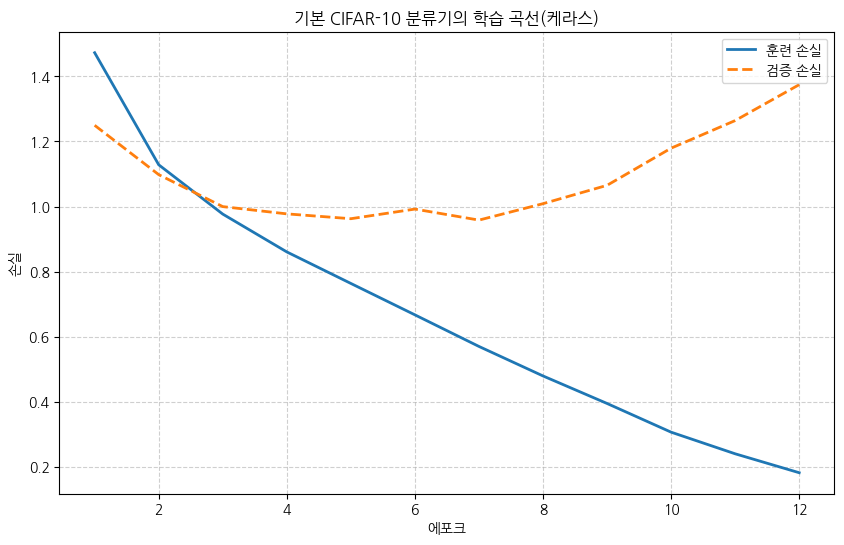

훈련 데이터셋 분류 정확도: 86.15%
평가 데이터셋 분류 정확도: 67.62%
두 정확도의 차이: 18.54%p


In [10]:
# 학습 곡선: 본문의 log.plot() 에 해당
viz.plot_histories(
    {'훈련 손실': history_base.history['loss'],
     '검증 손실': history_base.history['val_loss']},
    title='기본 CIFAR-10 분류기의 학습 곡선(케라스)', y_label='손실',
)

acc_train_base = get_accuracy(model, train_eval_loader)
acc_test_base = get_accuracy(model, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_base:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_base:.2f}%')
print(f'두 정확도의 차이: {acc_train_base - acc_test_base:.2f}%p')

본문과 마찬가지로 훈련 정확도와 평가 정확도의 차이가 크게 벌어진다. 과적합이다.
본문이 쓴 두 가지 처방, 데이터 증강과 드롭아웃을 케라스에서 적용해 보자.

## 5. 데이터 증강 — 본문 [코드 5-16]~[코드 5-18]과 대칭

본문은 여기에서 한 가지 번거로운 일을 해야 했다. `transforms.RandomHorizontalFlip()`은
**데이터셋에 붙는 변환**이라 훈련용인지 검증용인지 구분하지 못한다. 그래서 [코드 5-17]에서
증강을 적용한 데이터셋과 적용하지 않은 데이터셋을 각각 만들고, **같은 시드로** 분리해
훈련 쪽과 검증 쪽의 샘플이 겹치지 않게 맞춰야 했다.

케라스의 `layers.RandomFlip`은 **모델 안에 들어가는 계층**이다. 드롭아웃과 마찬가지로
학습할 때만 동작하고 평가할 때는 입력을 그대로 흘려보낸다. 훈련과 검증이 같은 데이터셋을
공유해도 문제가 없으므로, 데이터셋을 두 벌 만들 일이 없다.

앞의 `build_classifier(augment=True)`가 입력 계층 바로 뒤에 `RandomFlip`을 넣는다.
데이터 준비 코드는 손댈 필요가 없다.

In [11]:
keras.utils.set_random_seed(SEED)
model_aug = build_classifier(augment=True)
history_aug = compile_and_fit(model_aug)

acc_train_aug = get_accuracy(model_aug, train_eval_loader)
acc_test_aug = get_accuracy(model_aug, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_aug:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_aug:.2f}%')
print(f'두 정확도의 차이: {acc_train_aug - acc_test_aug:.2f}%p')

Epoch 1/20


313/313 - 11s - 35ms/step - accuracy: 0.4824 - loss: 1.4552 - val_accuracy: 0.5669 - val_loss: 1.2210


Epoch 2/20


313/313 - 11s - 35ms/step - accuracy: 0.6048 - loss: 1.1195 - val_accuracy: 0.6278 - val_loss: 1.0588


Epoch 3/20


...

Epoch 12/20


313/313 - 15s - 48ms/step - accuracy: 0.8393 - loss: 0.4681 - val_accuracy: 0.7308 - val_loss: 0.8146


Epoch 13/20


313/313 - 11s - 35ms/step - accuracy: 0.8523 - loss: 0.4341 - val_accuracy: 0.7294 - val_loss: 0.8425


훈련 데이터셋 분류 정확도: 81.13%
평가 데이터셋 분류 정확도: 72.74%
두 정확도의 차이: 8.39%p


In [12]:
# RandomFlip 이 학습 모드에서만 동작하는지 확인
sample = train_set[0][0].unsqueeze(0)               # (1, 3, 32, 32)
flip_layer = layers.RandomFlip('horizontal')

keras.utils.set_random_seed(SEED)
original = keras.ops.convert_to_numpy(sample)


def count_flipped(training):
    # 열 개의 출력 중 입력과 달라진(좌우 반전된) 것의 개수를 셈
    outputs = [flip_layer(sample, training=training) for _ in range(10)]
    return sum(not np.array_equal(keras.ops.convert_to_numpy(out), original)
               for out in outputs)


flipped_in_train = count_flipped(training=True)
flipped_in_eval = count_flipped(training=False)
print(f'학습 모드에서 반전된 횟수: {flipped_in_train} / 10')
print(f'평가 모드에서 반전된 횟수: {flipped_in_eval} / 10')

학습 모드에서 반전된 횟수: 6 / 10
평가 모드에서 반전된 횟수: 0 / 10


## 6. 드롭아웃 — 본문 [코드 5-19]와 대칭

본문은 분류기의 은닉층과 출력층 사이에 `nn.Dropout(p=0.5)`를 넣었다.
케라스에서는 같은 자리에 `layers.Dropout(0.5)`를 넣는다. 인자 이름이 `p`가 아니라
위치 인자라는 점 말고는 같다.

본문이 "드롭아웃은 학습 모드에서만 동작하고 평가 모드에서는 동작하지 않는다"고 설명하면서
`model.train()`과 `model.eval()`을 강조한 부분은 케라스에서 사라진다.
`fit()`은 학습 모드로, `evaluate()`와 `predict()`는 평가 모드로 자동으로 전환하기 때문이다.
모드 전환을 잊어 생기는 실수가 원천적으로 막히는 대신, 모드가 바뀌는 지점이 코드에
드러나지 않는다는 점은 알아 두어야 한다.

본문과 마찬가지로 조기 종료까지 걸리는 에포크가 늘어나므로 전체 에포크 수를 30으로 늘린다.

In [13]:
keras.utils.set_random_seed(SEED)
model_dropout = build_classifier(augment=True, dropout=True)
history_dropout = compile_and_fit(model_dropout, epochs=30)

acc_train_dropout = get_accuracy(model_dropout, train_eval_loader)
acc_test_dropout = get_accuracy(model_dropout, test_loader)
print(f'훈련 데이터셋 분류 정확도: {acc_train_dropout:.2f}%')
print(f'평가 데이터셋 분류 정확도: {acc_test_dropout:.2f}%')
print(f'두 정확도의 차이: {acc_train_dropout - acc_test_dropout:.2f}%p')

Epoch 1/30


313/313 - 15s - 48ms/step - accuracy: 0.4345 - loss: 1.5824 - val_accuracy: 0.5432 - val_loss: 1.2849


Epoch 2/30


313/313 - 12s - 37ms/step - accuracy: 0.5533 - loss: 1.2540 - val_accuracy: 0.6067 - val_loss: 1.1100


Epoch 3/30


...

Epoch 22/30


313/313 - 14s - 45ms/step - accuracy: 0.7987 - loss: 0.5686 - val_accuracy: 0.7340 - val_loss: 0.7858


Epoch 23/30


313/313 - 11s - 34ms/step - accuracy: 0.7990 - loss: 0.5596 - val_accuracy: 0.7415 - val_loss: 0.7775


훈련 데이터셋 분류 정확도: 84.87%
평가 데이터셋 분류 정확도: 74.09%
두 정확도의 차이: 10.79%p


In [14]:
# 세 모델의 학습 결과 비교: 본문 [표 5-5] 에 해당
rows = [
    ('기본 모델', history_base, acc_train_base, acc_test_base),
    ('증강 적용', history_aug, acc_train_aug, acc_test_aug),
    ('증강 + 드롭아웃', history_dropout, acc_train_dropout, acc_test_dropout),
]

print(f'{"구분":<10} {"최적 에포크":>8} {"훈련 손실":>10} {"검증 손실":>10} '
      f'{"훈련 정확도":>10} {"평가 정확도":>10} {"차이":>8}')
for name, history, acc_train, acc_test in rows:
    best_epoch = int(np.argmin(history.history['val_loss']))
    print(f'{name:<10} {best_epoch + 1:>10} '
          f'{history.history["loss"][best_epoch]:>12.4f} '
          f'{history.history["val_loss"][best_epoch]:>12.4f} '
          f'{acc_train:>13.2f} {acc_test:>13.2f} {acc_train - acc_test:>10.2f}')

구분           최적 에포크      훈련 손실      검증 손실     훈련 정확도     평가 정확도       차이
기본 모델               7       0.5700       0.9583         86.15         67.62      18.54
증강 적용               8       0.6347       0.7992         81.13         72.74       8.39
증강 + 드롭아웃          18       0.6306       0.7572         84.87         74.09      10.79


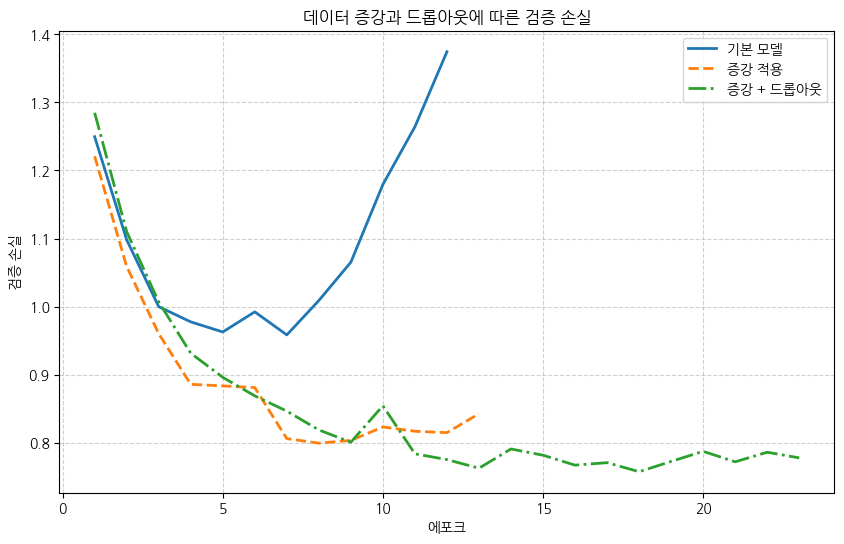

In [15]:
# 세 모델의 검증 손실 곡선 비교
viz.plot_histories(
    {'기본 모델': history_base.history['val_loss'],
     '증강 적용': history_aug.history['val_loss'],
     '증강 + 드롭아웃': history_dropout.history['val_loss']},
    title='데이터 증강과 드롭아웃에 따른 검증 손실', y_label='검증 손실',
)

## 7. 하드웨어 가속기 — 본문 [코드 5-20]~[코드 5-22]와 대칭

본문 [코드 5-20]은 `torch.cuda.is_available()`과 `torch.backends.mps.is_available()`을 확인해
장치 객체를 만들고, [코드 5-21]은 모델과 입력 텐서를 `.to(device)`로 옮겼다.
그리고 [코드 5-22]는 서드파티 라이브러리에 넘기기 위해 모델을 다시 CPU로 되돌렸다.

케라스에서는 이 세 코드가 모두 사라진다. 사용 가능한 가속기를 찾아 모델과 데이터를 옮기는 일을
케라스가 알아서 하기 때문이다. 위에서 이미 세 모델을 학습시켰는데 `.to(device)`를 한 번도
쓰지 않았다는 점을 떠올려 보자.

다만 파이토치 백엔드를 쓰고 있으므로, 가중치가 실제로 어느 장치에 올라가 있는지는
파이토치의 방식으로 확인할 수 있다.

In [16]:
# 본문 [코드 5-20]의 common.get_device() 에 해당하는 정보
print(f'파이토치가 보고한 장치: {common.get_device()}')

# 케라스가 실제로 가중치를 올려 둔 장치 (파이토치 백엔드이므로 torch 텐서로 확인 가능)
first_weight = model_dropout.weights[0].value
print(f'케라스 가중치가 올라간 장치: {first_weight.device}')

CUDA를 사용합니다.
파이토치가 보고한 장치: cuda
케라스 가중치가 올라간 장치: cuda:0


In [17]:
# 본문 [코드 5-22] 의 예측 부분에 해당
# 모델을 CPU 로 되돌리는 과정 없이 바로 예측할 수 있음
class_names = datasets.CIFAR10(root=data_root, train=False, download=False).classes

sample_image, sample_label = test_set[0]            # (3, 32, 32) 형태의 샘플
logits = model_dropout.predict(sample_image.unsqueeze(0), verbose=0)
predicted = logits.argmax(axis=1).item()

print(f'예측 클래스: {predicted} ({class_names[predicted]})')
print(f'실제 클래스: {sample_label} ({class_names[sample_label]})')

예측 클래스: 3 (cat)
실제 클래스: 3 (cat)


## 정리

- 케라스 3은 `KERAS_BACKEND` 환경 변수로 백엔드를 고른다. `'torch'`로 두면 파이토치 위에서 동작한다.
- `set_image_data_format('channels_first')`로 맞추면 `torchvision`의 텐서를 변환 없이 쓸 수 있고,
  파이토치 `DataLoader`도 `fit()`에 그대로 넘길 수 있다.
- 본문의 학습 루프 함수 60여 줄이 `compile()`과 `fit()` 두 호출로 줄어들고,
  조기 종료는 `EarlyStopping` 콜백이 대신한다.
- `.to(device)`와 `model.train()`/`model.eval()`을 쓰지 않는다. 케라스가 대신 처리한다.
- 편해진 만큼 드러나지 않는 것도 생긴다. 학습 루프 안에서 무슨 일이 일어나는지,
  모드가 언제 바뀌는지가 코드에 보이지 않는다. 본문이 학습 함수를 직접 만들어 본 이유이기도 하다.

## 연습 문제

**1.** `build_classifier()`가 만든 케라스 모델과 `CIFAR10ConvClassifier()`가 만든 파이토치 모델의
**계층별** 파라미터 수를 각각 출력해 나란히 비교해 보자.
케라스는 `model.summary()`, 파이토치는 `common.count_params()`를 각 하위 모듈에 적용하면 된다.

> 힌트: 파이토치 모델은 `named_children()`으로 하위 모듈을 순회할 수 있다.

**2.** 3절에서 `padding='same'` 대신 `padding='valid'`(패딩 없음)로 바꾸면
`Flatten()` 뒤의 텐서 크기가 어떻게 달라지는지 `summary()`로 확인해 보자.
그리고 본문이 왜 `padding`을 2와 1로 지정했는지 설명해 보자.

**3.** 4절의 `compile()`에서 `from_logits=True`를 빼면 어떤 일이 벌어질까?
먼저 예상해 본 다음 실제로 학습시켜 정확도를 확인하고, 왜 그런 결과가 나오는지 설명해 보자.

**4.** `EarlyStopping` 콜백에서 `restore_best_weights=False`(기본값)로 두고 학습시킨 뒤
평가 정확도를 측정해 보자. `True`일 때와 얼마나 차이가 나는지 확인하고,
본문의 `best_model_params` 변수가 왜 필요했는지 설명해 보자.

**5.** 5절의 `layers.RandomFlip('horizontal')`을 `'horizontal_and_vertical'`로 바꿔 학습해 보자.
평가 정확도가 어떻게 달라지는지 확인하고, CIFAR-10 이미지의 성격과 연결해 그 이유를 설명해 보자.

**6.** [도전 문제] 케라스에는 `EarlyStopping` 외에도 여러 콜백이 있다.
`keras.callbacks.ReduceLROnPlateau`를 추가해 검증 손실이 나아지지 않을 때 학습률을 줄이도록 하고,
학습 곡선이 어떻게 달라지는지 관찰해 보자.

**7.** [도전 문제] 이 노트북은 `keras.Sequential`로 모델을 만들었다.
`keras.Model`을 상속한 클래스로 같은 모델을 다시 만들어 보자.
본문의 `nn.Module` 상속 방식과 무엇이 같고 무엇이 다른지 정리해 보자.

> 힌트: `__init__()`에서 계층을 만들고 `call()`에서 이어 붙인다. 파이토치의 `forward()`에 해당하는 것이 `call()`이다.